In [7]:
import os
import zipfile
import requests
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Download and Extract the Dataset
url = "https://data.mendeley.com/public-files/datasets/2h76672znt/files/9031138a-b812-433e-a704-8acb1707936e/file_downloaded"
dataset_zip = "isolated_words_per_user.zip"
response = requests.get(url, stream=True)
with open(dataset_zip, "wb") as file:
    for chunk in response.iter_content(chunk_size=1024):
        file.write(chunk)

with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(".")
print("Dataset downloaded and extracted.")

# Step 2: Data Preparation and Preprocessing
def preprocess_image(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found at path: {image_path}")
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Failed to load image from path: {image_path}")
    image = cv2.resize(image, (128, 128))  # Resize to uniform dimensions
    return image

def load_dataset(base_path):
    data = []
    labels = []
    file_paths = []
    for user_folder in os.listdir(base_path):
        user_path = os.path.join(base_path, user_folder)
        if os.path.isdir(user_path):
            for file_name in os.listdir(user_path):
                if file_name.endswith('.png'):
                    image_path = os.path.join(user_path, file_name)
                    try:
                        # Extract the user ID (e.g., "userXXX") as the label
                        user_id = file_name.split('_')[0]  # First part of the filename
                        image = preprocess_image(image_path)
                        data.append(image)
                        labels.append(user_id)  # Use user ID as the label
                        file_paths.append(image_path)
                    except Exception as e:
                        print(f"Error processing file {file_name}: {e}")
    return np.array(data), np.array(labels), file_paths

# Load the dataset
base_path = "./isolated_words_per_user"
images, labels, file_paths = load_dataset(base_path)
print(f"Dataset loaded with {len(images)} images.")

# Split into training and testing sets
X_train, X_test, y_train, y_test, train_file_paths, test_file_paths = train_test_split(
    images, labels, file_paths, test_size=0.2, random_state=42, stratify=labels)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# Step 3: Feature Extraction
sift = cv2.SIFT_create()
orb = cv2.ORB_create()

def extract_features(image, method="SIFT"):
    if method == "SIFT":
        keypoints, descriptors = sift.detectAndCompute(image, None)
    elif method == "ORB":
        keypoints, descriptors = orb.detectAndCompute(image, None)
    return keypoints, descriptors

def extract_features_dataset(images, method="SIFT"):
    feature_list = []
    for image in images:
        _, descriptors = extract_features(image, method=method)
        feature_list.append(descriptors)
    return feature_list

sift_features_train = extract_features_dataset(X_train, method="SIFT")
orb_features_train = extract_features_dataset(X_train, method="ORB")

print("Feature extraction completed.")

# Step 4: Convert Features to a Format Suitable for Classification
def create_bow_histograms(features_list, kmeans_model):
    histograms = []
    for features in features_list:
        if features is not None:
            words = kmeans_model.predict(features)
            histogram, _ = np.histogram(words, bins=np.arange(kmeans_model.n_clusters + 1))
            histograms.append(histogram)
        else:
            histograms.append(np.zeros(kmeans_model.n_clusters))
    return np.array(histograms)

# Use k-means clustering to create a visual vocabulary
n_clusters = 500
sift_features_flattened = np.vstack([desc for desc in sift_features_train if desc is not None])
orb_features_flattened = np.vstack([desc for desc in orb_features_train if desc is not None])

print("Performing k-means clustering for SIFT...")
kmeans_sift = KMeans(n_clusters=n_clusters, random_state=42).fit(sift_features_flattened)
sift_histograms_train = create_bow_histograms(sift_features_train, kmeans_sift)

print("Performing k-means clustering for ORB...")
kmeans_orb = KMeans(n_clusters=n_clusters, random_state=42).fit(orb_features_flattened)
orb_histograms_train = create_bow_histograms(orb_features_train, kmeans_orb)

# Standardize the histograms
scaler = StandardScaler()
sift_histograms_train = scaler.fit_transform(sift_histograms_train)
orb_histograms_train = scaler.fit_transform(orb_histograms_train)

# Step 5: Train the SVM classifiers
svm_sift = SVC(kernel="linear", random_state=42)
svm_orb = SVC(kernel="linear", random_state=42)

print("Training SVM for SIFT...")
svm_sift.fit(sift_histograms_train, y_train)

print("Training SVM for ORB...")
svm_orb.fit(orb_histograms_train, y_train)

# Step 6: Evaluate the Models
def evaluate_model(images, labels, file_paths, method="SIFT"):
    correct_predictions = 0
    total_predictions = len(images)

    for i in range(total_predictions):
        image = images[i]
        true_user = labels[i]  # True user is extracted from labels
        file_path = file_paths[i]  # Get the file path for the current image

        _, descriptors = extract_features(image, method=method)

        if descriptors is not None:
            histogram = create_bow_histograms([descriptors], kmeans_sift if method == "SIFT" else kmeans_orb)
        else:
            histogram = np.zeros((1, n_clusters))

        histogram = scaler.transform(histogram)

        predicted_user = svm_sift.predict(histogram)[0] if method == "SIFT" else svm_orb.predict(histogram)[0]

        if predicted_user == true_user:
            correct_predictions += 1
            print(f"{method} | Image: {os.path.basename(file_path)} | True User: {true_user} | Predicted User: {predicted_user} | Correct Prediction")
        else:
            print(f"{method} | Image: {os.path.basename(file_path)} | True User: {true_user} | Predicted User: {predicted_user} | Incorrect Prediction")

    accuracy = correct_predictions / total_predictions
    return correct_predictions, total_predictions, accuracy

# Evaluate SIFT model
sift_correct, sift_total, sift_accuracy = evaluate_model(X_test, y_test, test_file_paths, method="SIFT")

# Evaluate ORB model
orb_correct, orb_total, orb_accuracy = evaluate_model(X_test, y_test, test_file_paths, method="ORB")

# Print Results
print("------------------------------------------------------------------------------------------\n")
print(f"SIFT Correct Predictions: {sift_correct}/{sift_total}, Accuracy: {sift_accuracy:.2f}\n")
print("------------------------------------------------------------------------------------------\n")
print(f"ORB Correct Predictions: {orb_correct}/{orb_total}, Accuracy: {orb_accuracy:.2f}\n")


Dataset downloaded and extracted.
Dataset loaded with 8144 images.
Training samples: 6515, Testing samples: 1629
Feature extraction completed.
Performing k-means clustering for SIFT...
Performing k-means clustering for ORB...
Training SVM for SIFT...
Training SVM for ORB...
SIFT | Image: user064_sakhar_018.png | True User: user064 | Predicted User: user039 | Incorrect Prediction
SIFT | Image: user031_mustadhafeen_030.png | True User: user031 | Predicted User: user070 | Incorrect Prediction
SIFT | Image: user024_mustadhafeen_027.png | True User: user024 | Predicted User: user015 | Incorrect Prediction
SIFT | Image: user005_mustadhafeen_021.png | True User: user005 | Predicted User: user066 | Incorrect Prediction
SIFT | Image: user064_mustadhafeen_026.png | True User: user064 | Predicted User: user036 | Incorrect Prediction
SIFT | Image: user009_ghaleez_016.png | True User: user009 | Predicted User: user050 | Incorrect Prediction
SIFT | Image: user079_mustadhafeen_028.png | True User: us

In [15]:
# Function to calculate and display key point matching accuracy
def calculate_keypoint_matching_accuracy(correct, total, total_keypoints, matched_keypoints):
    accuracy = (matched_keypoints / total_keypoints) * 100 if total_keypoints > 0 else 0.0
    print(f"Total Key Points: {total_keypoints}")
    print(f"Matched Key Points: {matched_keypoints}")
    print(f"Key Point Matching Accuracy: {accuracy:.2f}%\n")
    return accuracy

# SIFT Key Point Matching Evaluation
sift_total_keypoints = 0
sift_matched_keypoints = 0

for i in range(len(X_test)):
    image = X_test[i]
    true_user = y_test[i]

    # Detect keypoints and extract features
    keypoints, descriptors = extract_features(image, method="SIFT")
    num_keypoints = len(keypoints) if keypoints is not None else 0
    sift_total_keypoints += num_keypoints

    if descriptors is not None:
        histogram = create_bow_histograms([descriptors], kmeans_sift)
    else:
        histogram = np.zeros((1, n_clusters))

    histogram = scaler.transform(histogram)
    predicted_user = svm_sift.predict(histogram)[0]

    if predicted_user == true_user:
        sift_matched_keypoints += num_keypoints

print("Key Point Matching Accuracy for SIFT:")
sift_accuracy = calculate_keypoint_matching_accuracy(
    sift_correct, sift_total, sift_total_keypoints, sift_matched_keypoints
)

# ORB Key Point Matching Evaluation
orb_total_keypoints = 0
orb_matched_keypoints = 0

for i in range(len(X_test)):
    image = X_test[i]
    true_user = y_test[i]

    # Detect keypoints and extract features
    keypoints, descriptors = extract_features(image, method="ORB")
    num_keypoints = len(keypoints) if keypoints is not None else 0
    orb_total_keypoints += num_keypoints

    if descriptors is not None:
        histogram = create_bow_histograms([descriptors], kmeans_orb)
    else:
        histogram = np.zeros((1, n_clusters))

    histogram = scaler.transform(histogram)
    predicted_user = svm_orb.predict(histogram)[0]

    if predicted_user == true_user:
        orb_matched_keypoints += num_keypoints

print("Key Point Matching Accuracy for ORB:")
orb_accuracy = calculate_keypoint_matching_accuracy(
    orb_correct, orb_total, orb_total_keypoints, orb_matched_keypoints
)

Key Point Matching Accuracy for SIFT:
Total Key Points: 73976
Matched Key Points: 12230
Key Point Matching Accuracy: 16.53%

Key Point Matching Accuracy for ORB:
Total Key Points: 138939
Matched Key Points: 16529
Key Point Matching Accuracy: 11.90%



In [16]:
#Record Execution Time for Feature Extraction and Matching

import time

def record_execution_time(method, extract_features_func, match_func, test_images, train_histograms, kmeans_model, scaler, svm_model, true_labels):
    """
    Record the execution time for feature extraction and matching.

    Args:
        method: String indicating the feature extraction method (e.g., "SIFT" or "ORB").
        extract_features_func: Function to extract features for the dataset.
        match_func: Function to compute Bag-of-Words histograms and classify images.
        test_images: Test images to process.
        train_histograms: Bag-of-Words histograms for training images.
        kmeans_model: Trained KMeans model.
        scaler: Scaler for standardizing histograms.
        svm_model: Trained SVM model for classification.
        true_labels: Ground truth labels for test images.

    Returns:
        execution_time: Time taken for the entire process in seconds.
    """
    start_time = time.time()

    # Feature extraction
    features_test = extract_features_func(test_images, method=method)

    # Bag-of-Words histograms and classification
    histograms_test = scaler.transform(create_bow_histograms(features_test, kmeans_model))
    predicted_labels = svm_model.predict(histograms_test)

    end_time = time.time()
    execution_time = end_time - start_time

    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"{method} Accuracy: {accuracy * 100:.2f}%")
    print(f"{method} Execution Time: {execution_time:.2f} seconds")
    return execution_time

# Record execution time for SIFT and ORB
sift_execution_time = record_execution_time(
    method="SIFT",
    extract_features_func=extract_features_dataset,
    match_func=create_bow_histograms,
    test_images=X_test,
    train_histograms=sift_histograms_train,
    kmeans_model=kmeans_sift,
    scaler=scaler,
    svm_model=svm_sift,
    true_labels=y_test
)

orb_execution_time = record_execution_time(
    method="ORB",
    extract_features_func=extract_features_dataset,
    match_func=create_bow_histograms,
    test_images=X_test,
    train_histograms=orb_histograms_train,
    kmeans_model=kmeans_orb,
    scaler=scaler,
    svm_model=svm_orb,
    true_labels=y_test
)


SIFT Accuracy: 14.98%
SIFT Execution Time: 16.48 seconds
ORB Accuracy: 12.71%
ORB Execution Time: 7.46 seconds


In [17]:
#Test Robustness of SIFT and ORB Against Variations

def apply_transformations(image, scale=1.0, rotation=0, brightness=0, noise_level=0):
    """
    Apply transformations to an image for robustness testing.

    Args:
        image: Input image (grayscale).
        scale: Scaling factor (default is 1.0, no scaling).
        rotation: Rotation angle in degrees (default is 0).
        brightness: Brightness adjustment value (positive or negative).
        noise_level: Standard deviation of Gaussian noise to add (default is 0, no noise).

    Returns:
        Transformed image.
    """
    # Scale
    h, w = image.shape
    scaled_image = cv2.resize(image, (int(w * scale), int(h * scale)))

    # Rotate
    center = (scaled_image.shape[1] // 2, scaled_image.shape[0] // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, rotation, 1.0)
    rotated_image = cv2.warpAffine(scaled_image, rotation_matrix, (scaled_image.shape[1], scaled_image.shape[0]))

    # Adjust brightness
    brightness_image = cv2.convertScaleAbs(rotated_image, alpha=1, beta=brightness)

    # Add Gaussian noise
    if noise_level > 0:
        noise = np.random.normal(0, noise_level, brightness_image.shape).astype(np.uint8)
        noisy_image = cv2.add(brightness_image, noise)
    else:
        noisy_image = brightness_image

    return noisy_image

def evaluate_robustness(images, true_labels, method, kmeans_model, scaler, svm_model, scale=1.0, rotation=0, brightness=0, noise_level=0):
    """
    Evaluate the robustness of a feature extraction and matching method under transformations.

    Args:
        images: Test images to process.
        true_labels: Ground truth labels for the test images.
        method: Feature extraction method (e.g., "SIFT" or "ORB").
        kmeans_model: Trained KMeans model.
        scaler: Scaler for standardizing histograms.
        svm_model: Trained SVM model for classification.
        scale, rotation, brightness, noise_level: Transformation parameters.

    Returns:
        Accuracy of the method under the applied transformations.
    """
    # Apply transformations
    transformed_images = [apply_transformations(image, scale, rotation, brightness, noise_level) for image in images]

    # Extract features and classify
    features_test = extract_features_dataset(transformed_images, method=method)
    histograms_test = scaler.transform(create_bow_histograms(features_test, kmeans_model))
    predicted_labels = svm_model.predict(histograms_test)

    # Evaluate accuracy
    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"{method} Accuracy under transformations - Scale: {scale}, Rotation: {rotation}, Brightness: {brightness}, Noise: {noise_level}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    return accuracy

# Test transformations for SIFT and ORB
transform_params = [
    {"scale": 0.8, "rotation": 0, "brightness": 0, "noise_level": 0},  # Scale down
    {"scale": 1.2, "rotation": 0, "brightness": 0, "noise_level": 0},  # Scale up
    {"scale": 1.0, "rotation": 45, "brightness": 0, "noise_level": 0},  # Rotate
    {"scale": 1.0, "rotation": 0, "brightness": 50, "noise_level": 0},  # Increase brightness
    {"scale": 1.0, "rotation": 0, "brightness": -50, "noise_level": 0}, # Decrease brightness
    {"scale": 1.0, "rotation": 0, "brightness": 0, "noise_level": 10},  # Add noise
]

sift_robustness = []
orb_robustness = []

for params in transform_params:
    print(f"Testing SIFT robustness with transformations: {params}")
    sift_accuracy = evaluate_robustness(X_test, y_test, "SIFT", kmeans_sift, scaler, svm_sift, **params)
    sift_robustness.append((params, sift_accuracy))

    print(f"Testing ORB robustness with transformations: {params}")
    orb_accuracy = evaluate_robustness(X_test, y_test, "ORB", kmeans_orb, scaler, svm_orb, **params)
    orb_robustness.append((params, orb_accuracy))


Testing SIFT robustness with transformations: {'scale': 0.8, 'rotation': 0, 'brightness': 0, 'noise_level': 0}
SIFT Accuracy under transformations - Scale: 0.8, Rotation: 0, Brightness: 0, Noise: 0
Accuracy: 8.23%
Testing ORB robustness with transformations: {'scale': 0.8, 'rotation': 0, 'brightness': 0, 'noise_level': 0}
ORB Accuracy under transformations - Scale: 0.8, Rotation: 0, Brightness: 0, Noise: 0
Accuracy: 4.73%
Testing SIFT robustness with transformations: {'scale': 1.2, 'rotation': 0, 'brightness': 0, 'noise_level': 0}
SIFT Accuracy under transformations - Scale: 1.2, Rotation: 0, Brightness: 0, Noise: 0
Accuracy: 11.60%
Testing ORB robustness with transformations: {'scale': 1.2, 'rotation': 0, 'brightness': 0, 'noise_level': 0}
ORB Accuracy under transformations - Scale: 1.2, Rotation: 0, Brightness: 0, Noise: 0
Accuracy: 12.71%
Testing SIFT robustness with transformations: {'scale': 1.0, 'rotation': 45, 'brightness': 0, 'noise_level': 0}
SIFT Accuracy under transformation

Counting key points detected by SIFT...
Counting key points detected by ORB...

Comparison of Key Points Detected:
Average key points detected by SIFT: 45.41
Average key points detected by ORB: 85.29


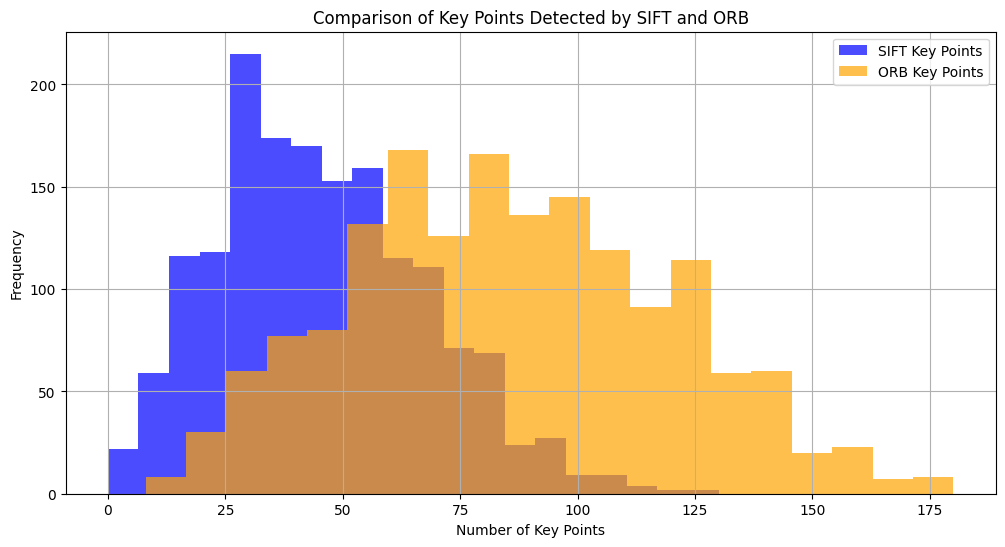

In [18]:
# Compare the Number of Key Points Detected by SIFT and ORB

def count_keypoints(images, method):
    """
    Count the number of key points detected by the given method.

    Args:
        images: List of images to process.
        method: Feature extraction method ("SIFT" or "ORB").

    Returns:
        List of key point counts for each image.
    """
    keypoint_counts = []
    for image in images:
        keypoints, _ = extract_features(image, method=method)
        keypoint_counts.append(len(keypoints))
    return keypoint_counts

# Count key points for SIFT and ORB
print("Counting key points detected by SIFT...")
sift_keypoint_counts = count_keypoints(X_test, method="SIFT")

print("Counting key points detected by ORB...")
orb_keypoint_counts = count_keypoints(X_test, method="ORB")

# Summarize results
print("\nComparison of Key Points Detected:")
print(f"Average key points detected by SIFT: {np.mean(sift_keypoint_counts):.2f}")
print(f"Average key points detected by ORB: {np.mean(orb_keypoint_counts):.2f}")

# Plotting the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(sift_keypoint_counts, bins=20, alpha=0.7, label="SIFT Key Points", color="blue")
plt.hist(orb_keypoint_counts, bins=20, alpha=0.7, label="ORB Key Points", color="orange")
plt.title("Comparison of Key Points Detected by SIFT and ORB")
plt.xlabel("Number of Key Points")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()
